In [1]:
#%matplotlib widget
%load_ext autoreload
%autoreload 2
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import tqdm
from cx import extrapolation
from cx.bee import *
from cx.plotting import plot_weights, plot_grouped_weights

In [2]:
# Construct extrapolator
kernel_parameters_by_roi = {}
next_index = 0
for roi in ROIS:
    #kernel_parameters_by_roi[roi], next_index = extrapolation.build_kernel_parameters(next_index, CELLS, columnar_kernel_size=3, symmetric_epgs=roi == "EB", epg_width=3 if roi == "PB" else 3)
    kernel_parameters_by_roi[roi], next_index = extrapolation.build_kernel_parameters(next_index, CELLS, columnar_kernel_size=3, symmetric_epgs=roi == "PB", epg_width=3 if roi == "PB" else 3, symmetric_delta7=False)

extrapolator = extrapolation.Extrapolator(ROIS, CELLS, COLUMNS_BY_ROI, PROJECTIONS, kernel_parameters_by_roi, kernel_parameter_count=next_index, closed_eb=False)
print(extrapolator.theta_len(), "parameters")

cell_labels = CELLS["type"] + "_" + CELLS["subtype"]
grouped_labels = extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"]

108 parameters


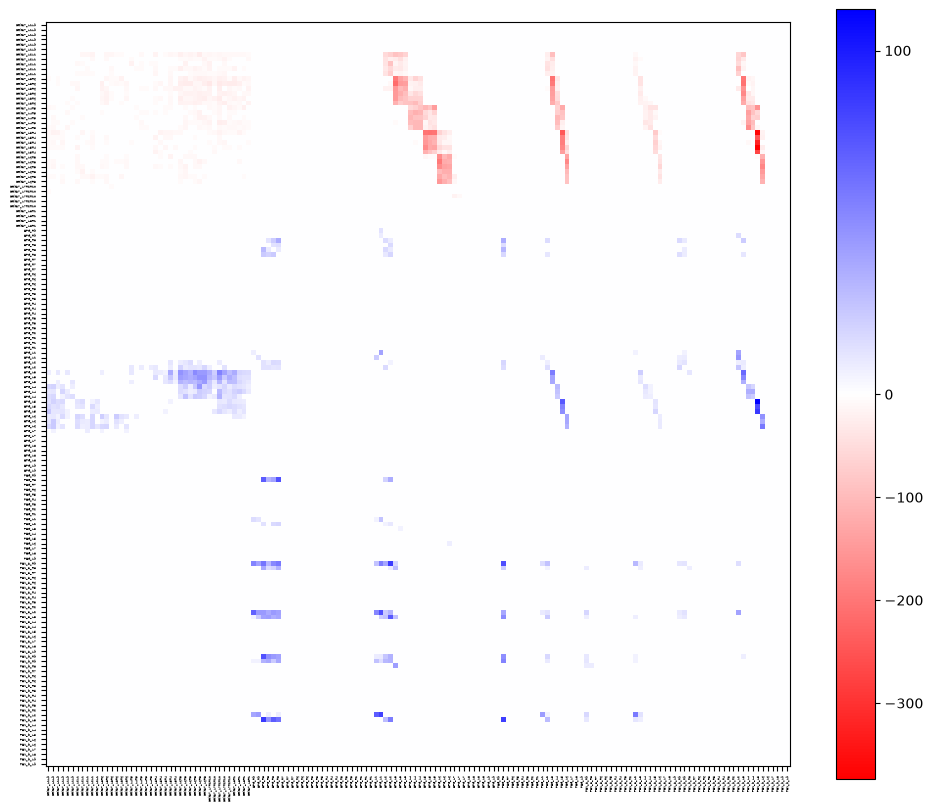

In [3]:
W_sample_signed = W_sample.copy()
W_sample_signed[:,CELLS["type"] == "Delta7",:] *= -1

#np.save("data/bee-sample-full.npy", W_sample_signed)
plot_weights(W_sample_signed.sum(0), cell_labels, figsize=(12, 10))

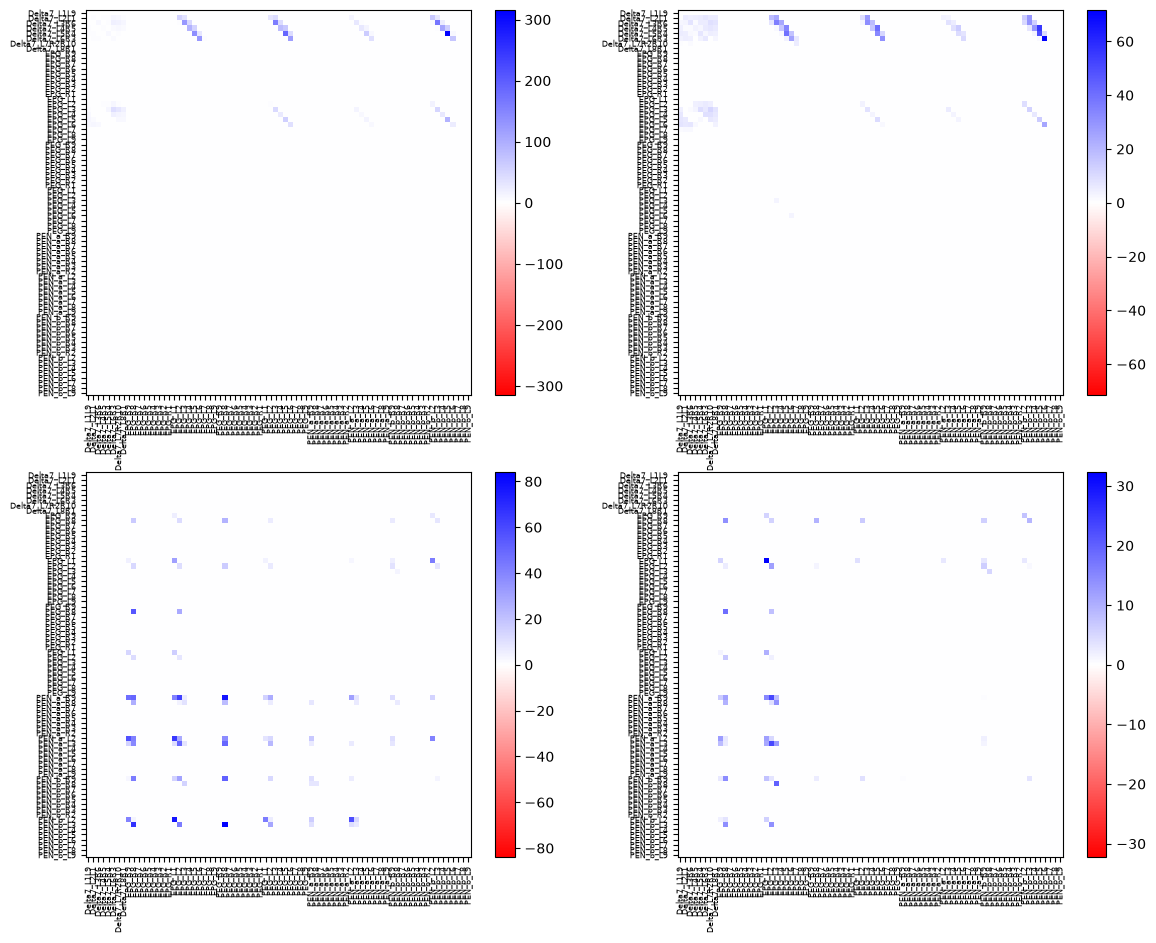

In [4]:
W_sample_mean_conn = extrapolator.group(W_sample)
W_sample_std_conn = np.sqrt(extrapolator.group_var(W_sample, W_sample_mean_conn))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))
plot_grouped_weights(W_sample_mean_conn[0,:,:], grouped_labels, ax=ax1)
plot_grouped_weights(W_sample_std_conn[0,:,:], grouped_labels, ax=ax2)
plot_grouped_weights(W_sample_mean_conn[1,:,:], grouped_labels, ax=ax3)
plot_grouped_weights(W_sample_std_conn[1,:,:], grouped_labels, ax=ax4)
plt.show()

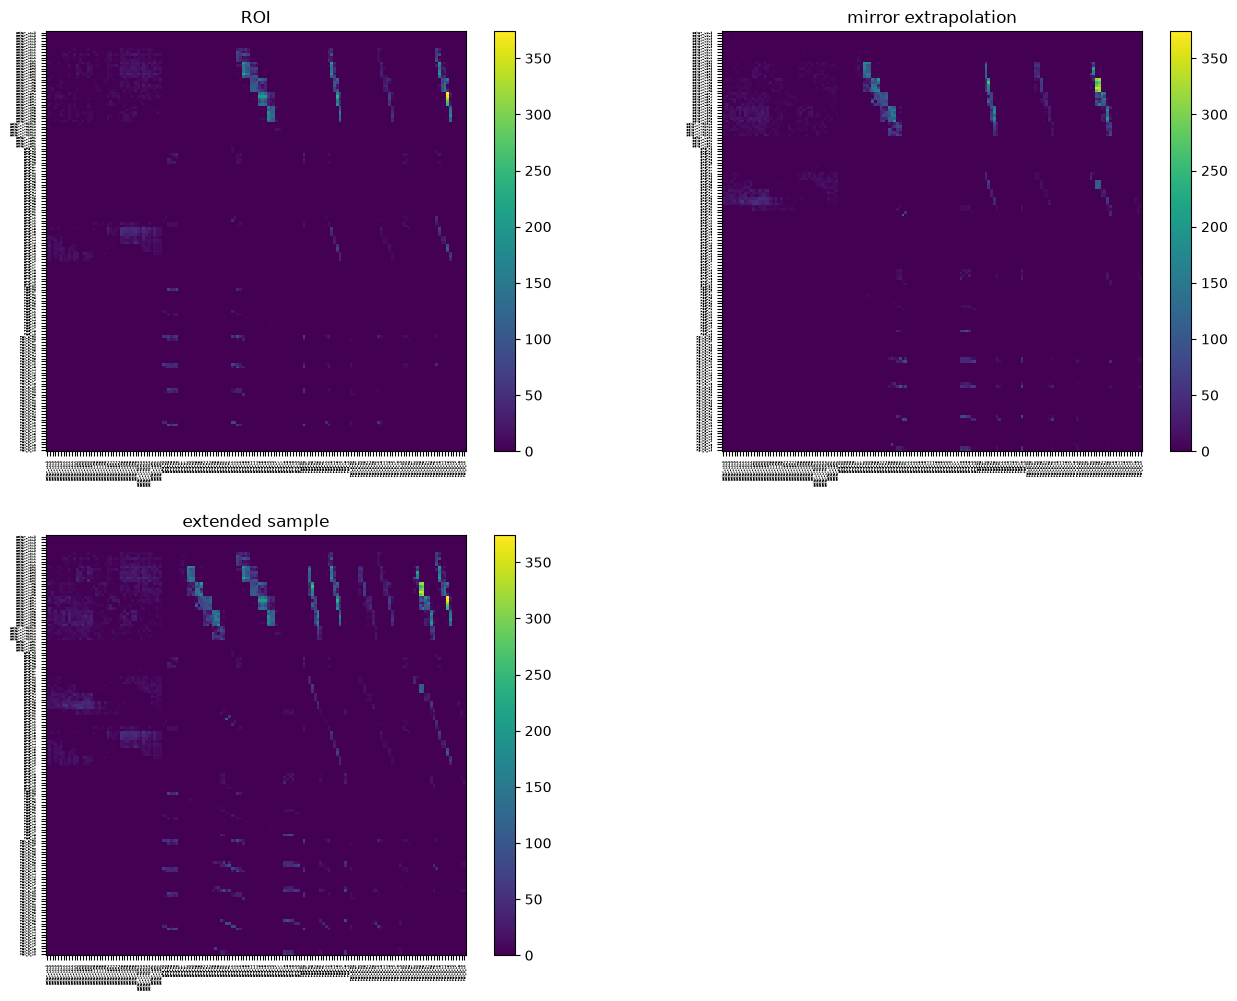

In [ ]:
mirror_map = pl.read_csv("../data/connectome/bee-cells-mirror.csv").with_row_index()
W_mirrored = np.zeros_like(W_sample)

for r in range(len(extrapolator.rois)):
    for i, (pre_type, pre_subtype, pre_indices) in enumerate(extrapolator.grouped.select("type", "subtype", "indices").rows()):
        for j, (post_type, post_subtype, post_indices) in enumerate(extrapolator.grouped.select("type", "subtype", "indices").rows()):
            count = len(pre_indices) * len(post_indices)
            if np.array_equal(pre_indices, post_indices):
                count -= len(pre_indices)
            if count <= 0:
                continue

            k = mirror_map.filter(type = pre_type, mirrored_subtype = pre_subtype)["index"][0]
            l = mirror_map.filter(type = post_type, mirrored_subtype = post_subtype)["index"][0]
            
            W_mirrored[np.ix_([r], pre_indices, post_indices)] = np.maximum(0, np.random.normal(loc=W_sample_mean_conn[r, k, l], scale=W_sample_std_conn[r, k, l], size=(len(pre_indices), len(post_indices))))

W_mirrored[0,...][np.eye(W_mirrored.shape[1], dtype=bool)] = 0
W_mirrored[1,...][np.eye(W_mirrored.shape[1], dtype=bool)] = 0
W_sample_extended = W_mirrored + W_sample

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
norm = TwoSlopeNorm()
ax1.set_title("ROI")
plot_weights(W_sample.sum(0), cell_labels, ax=ax1, norm=norm)
ax2.set_title("mirror extrapolation")
plot_weights(W_mirrored.sum(0), cell_labels, ax=ax2, norm=norm)
ax3.set_title("extended sample")
plot_weights(W_sample_extended.sum(0), cell_labels, ax=ax3, norm=norm)
ax4.remove()

plt.show()

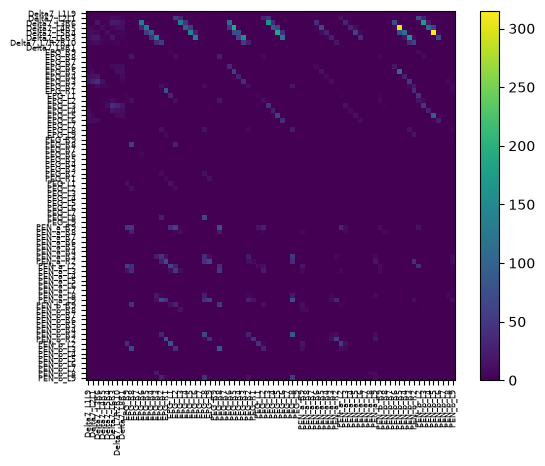

In [ ]:
W_sample_extended_mean_conn = extrapolator.group(W_sample_extended)

plot_grouped_weights(W_sample_extended_mean_conn.sum(0), grouped_labels)
plt.show()

In [ ]:
from scipy.optimize import least_squares

x0 = extrapolator.init_theta()
result = least_squares(lambda theta: (extrapolator.extrapolate(theta, SAMPLE) - W_sample_mean_conn).flatten(), jac=lambda theta: extrapolator.jacobian_extrapolate(theta, SAMPLE), x0 = x0, bounds=extrapolator.theta_bounds(), verbose=2, ftol=1e-7, x_scale="jac")
parameters = result.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5317e+04                                    3.70e+02    
       1              7         3.5317e+04      3.49e-02       2.04e+00       5.07e+02    
       2              8         3.5316e+04      6.95e-02       5.23e-01       5.04e+02    
       3              9         3.5316e+04      1.23e-01       1.05e+00       3.66e+02    
       4             11         3.5316e+04      1.76e-02       5.22e-01       4.98e+02    
       5             12         3.5316e+04      7.05e-03       3.75e-01       3.65e+02    
       6             13         3.5316e+04      1.73e-02       1.31e-01       3.65e+02    
       7             14         3.5316e+04      7.29e-03       2.62e-01       4.96e+02    
       8             15         3.5316e+04      8.59e-03       6.58e-02       4.96e+02    
       9             16         3.5316e+04      1.12e-02       1.32e-01       3.64e+02    

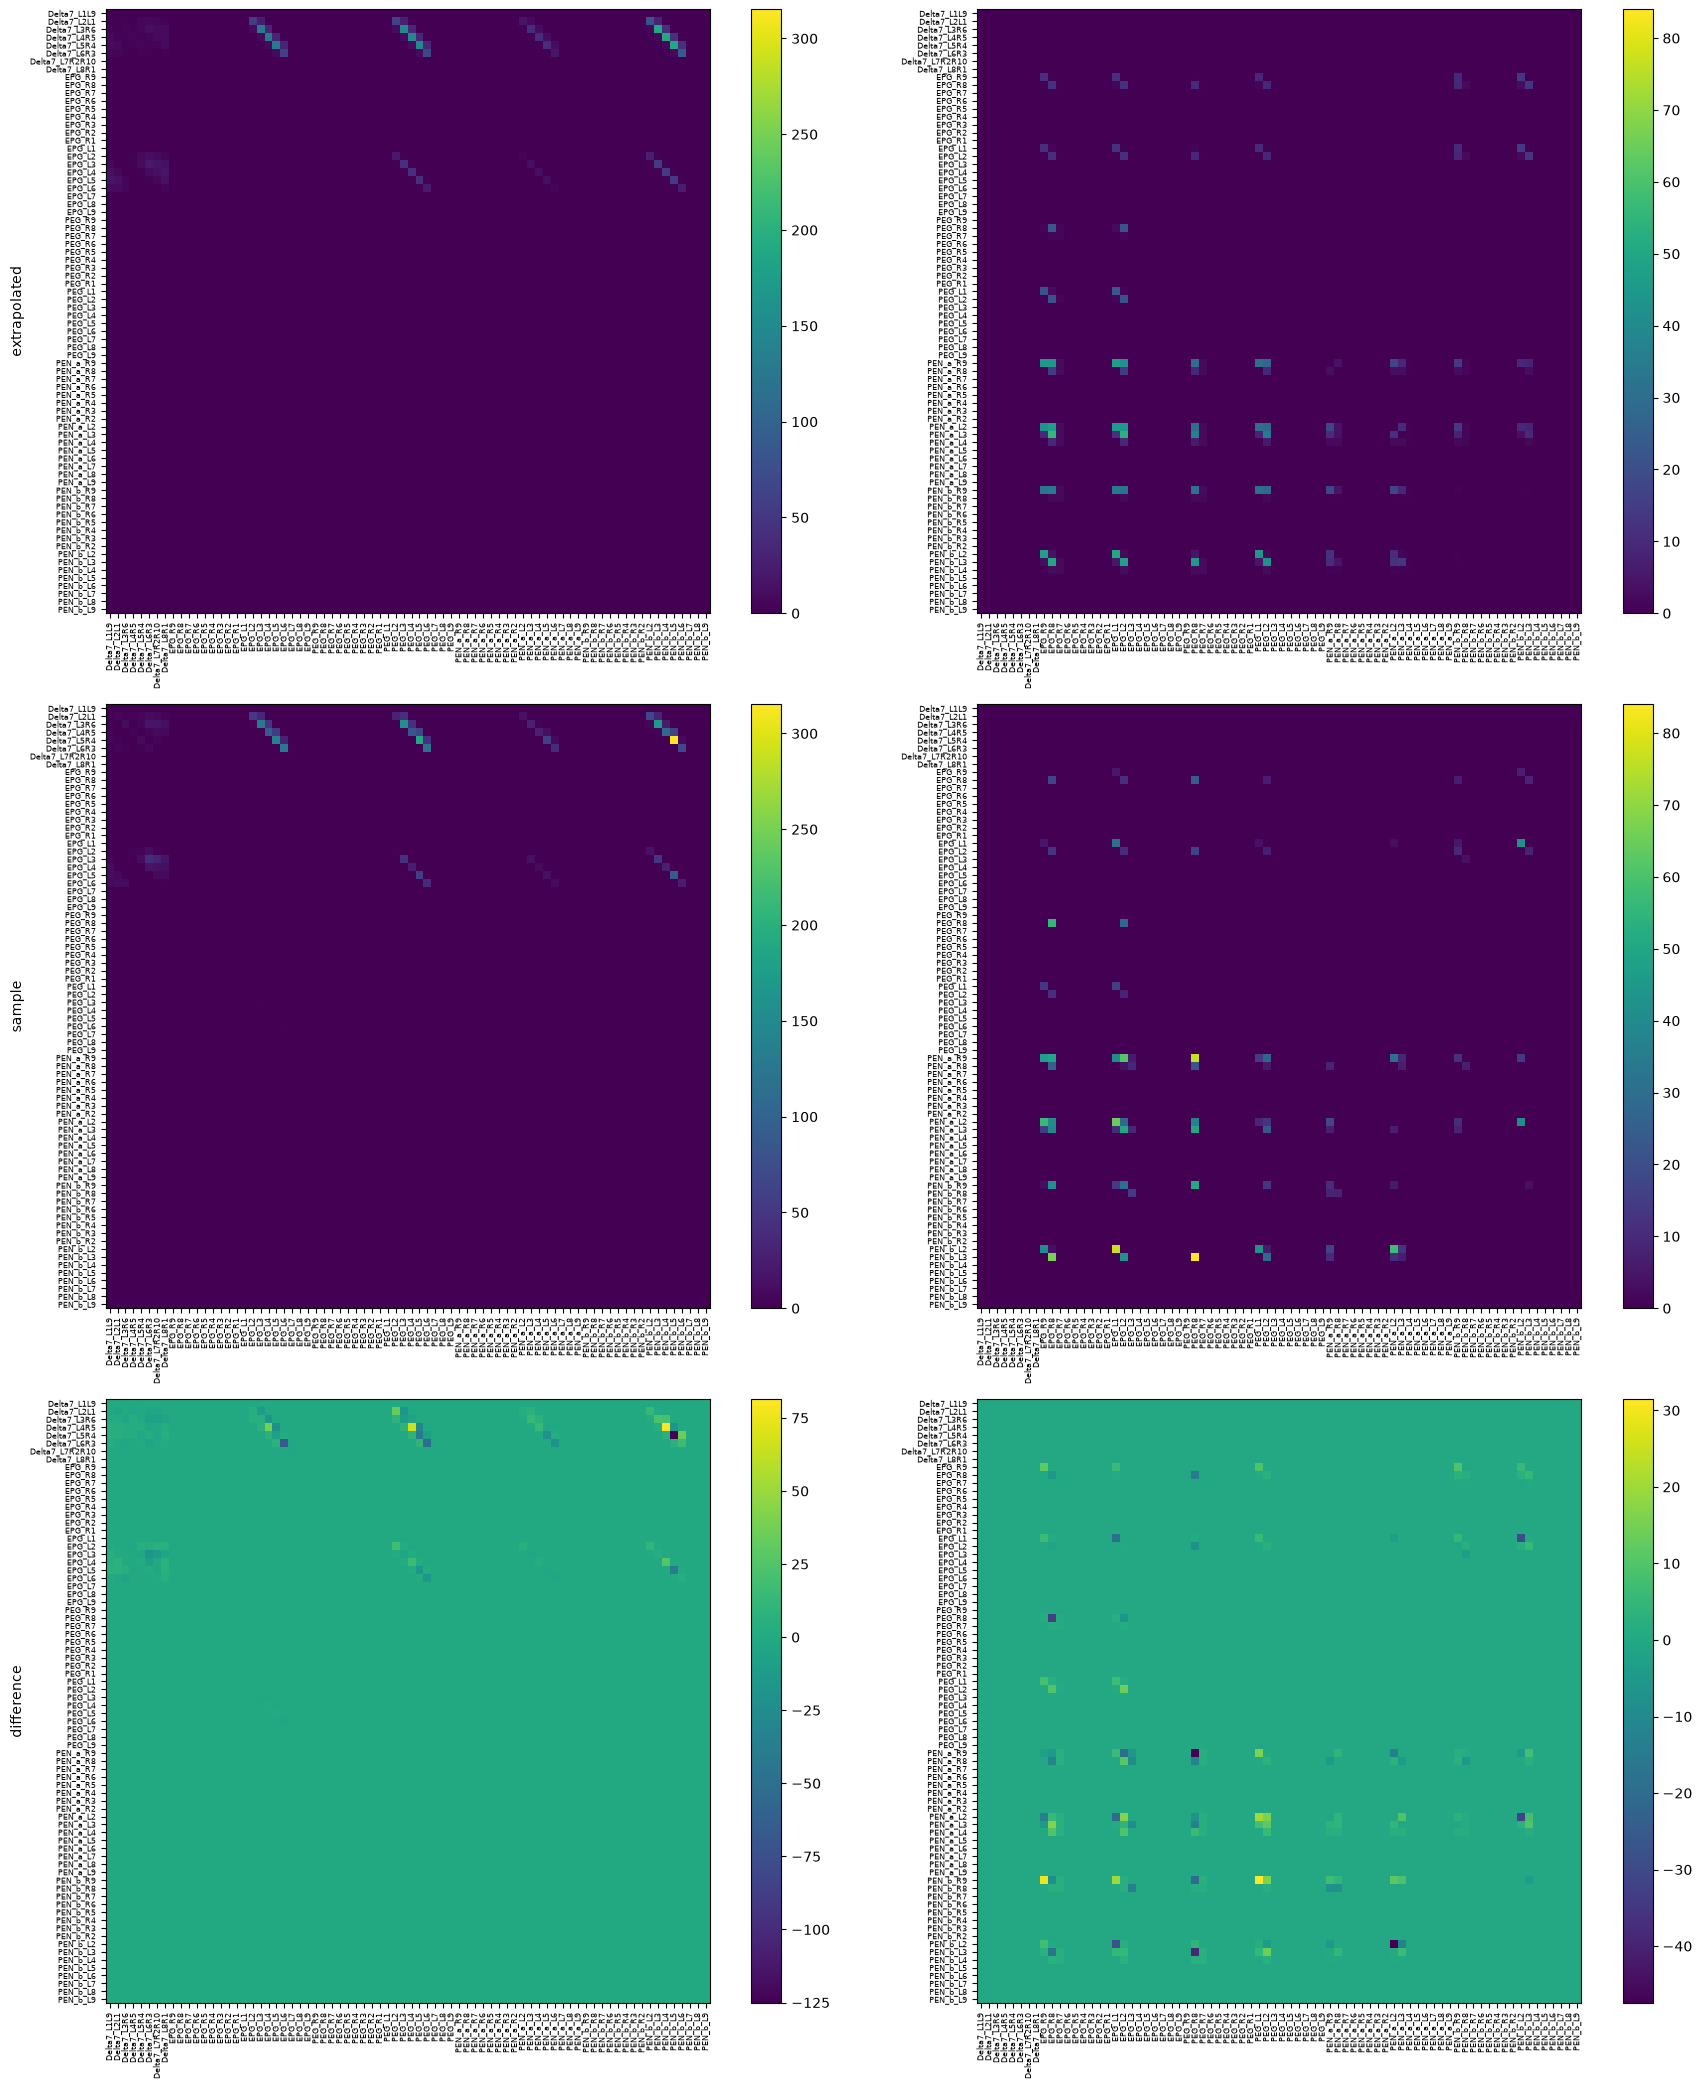

In [ ]:
W_extrapolated_mean_conn_sample = extrapolator.extrapolate(parameters, SAMPLE)

np.save("../results/data/connectome/bee-extrapolated-sample-mean.npy", W_extrapolated_mean_conn_sample)
np.save("../results/data/connectome/bee-sample-mean.npy", W_sample_mean_conn)

norm_pb = plt.Normalize(vmin=0, vmax=np.maximum(W_extrapolated_mean_conn_sample[0,...].max(), W_sample_mean_conn[0,...].max()))
norm_eb = plt.Normalize(vmin=0, vmax=np.maximum(W_extrapolated_mean_conn_sample[1,...].max(), W_sample_mean_conn[1,...].max()))
fig, axes = plt.subplots(3, 2, figsize=(18, 21))
axes[0][0].set_ylabel("extrapolated")
plot_grouped_weights(W_extrapolated_mean_conn_sample[0,...], grouped_labels, ax=axes[0][0], norm=norm_pb)
plot_grouped_weights(W_extrapolated_mean_conn_sample[1,...], grouped_labels, ax=axes[0][1], norm=norm_eb)
axes[1][0].set_ylabel("sample")
plot_grouped_weights(W_sample_mean_conn[0,...], grouped_labels, ax=axes[1][0], norm=norm_pb)
plot_grouped_weights(W_sample_mean_conn[1,...], grouped_labels, ax=axes[1][1], norm=norm_eb)
axes[2][0].set_ylabel("difference")
plot_grouped_weights(W_extrapolated_mean_conn_sample[0,...] - W_sample_mean_conn[0,...], grouped_labels, ax=axes[2][0])
plot_grouped_weights(W_extrapolated_mean_conn_sample[1,...] - W_sample_mean_conn[1,...], grouped_labels, ax=axes[2][1])
plt.tight_layout()
plt.show()

36380.5703126924


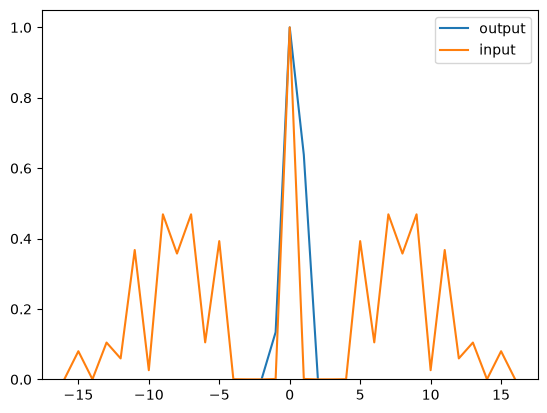

In [16]:
output_kernel, input_kernel = extrapolator.extract_kernels(parameters, "PB", "Delta7")
print(extrapolator.extract_scale(parameters, 0, 0, 0))
print(input_kernel)

plt.figure()
plt.plot(*output_kernel.visualize(), label="output")
plt.plot(*input_kernel.visualize(), label="input")

#offsets, input_kernel_curve = input_kernel.visualize()
#plt.plot(offsets, np.max([input_kernel_curve, np.roll(input_kernel_curve, 1)], axis=0))
plt.ylim(bottom=0)
plt.legend()
plt.show()

/tmp/ipykernel_2025324/1584740174.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


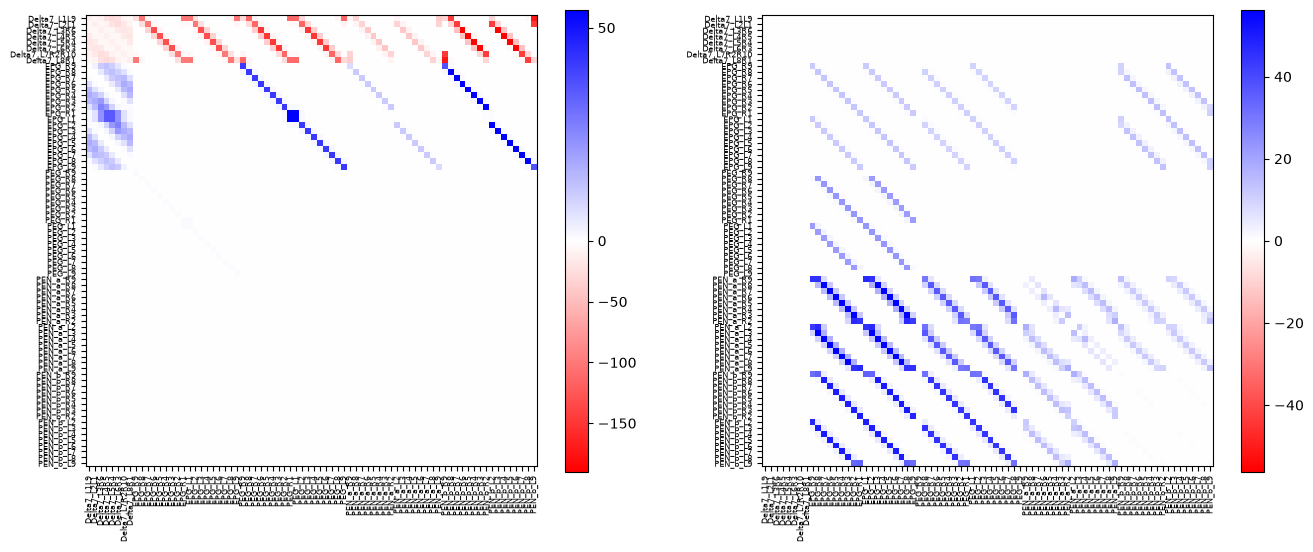

In [ ]:
W_extrapolated_mean_conn = extrapolator.extrapolate(parameters, COLUMNS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_grouped_weights(W_extrapolated_mean_conn[0,...], grouped_labels, ax=ax1, label="PB")
plot_grouped_weights(W_extrapolated_mean_conn[1,...], grouped_labels, ax=ax2, label="EB")
plt.show()

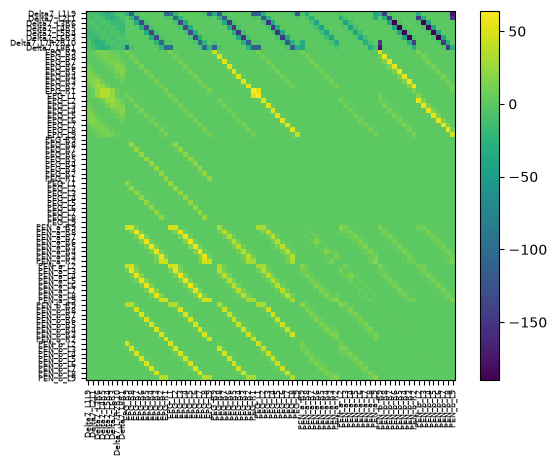

In [ ]:
W_extrapolated_mean_conn = extrapolator.extrapolate(parameters, COLUMNS)

#plt.figure(figsize=(12, 10))
#plot_grouped_weights(W_extrapolated_mean_conn.sum(0), extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"], ax=plt.gca())
#plt.show()
W_extrapolated_mean_conn_signed = W_extrapolated_mean_conn.copy()
W_extrapolated_mean_conn_signed[:,extrapolator.grouped["type"] == "Delta7",:] *= -1
np.save("../results/data/connectome/bee-mean-conn.npy", W_extrapolated_mean_conn_signed)
plot_grouped_weights(W_extrapolated_mean_conn_signed.sum(0), extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"])

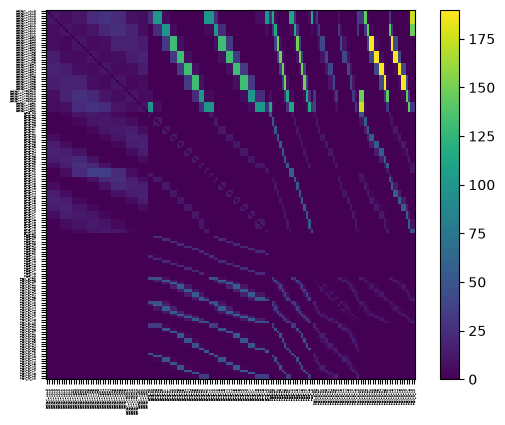

In [13]:
W_extrapolated = np.zeros((len(ROIS), len(CELLS), len(CELLS)))

for ti, ii in enumerate(extrapolator.grouped["indices"]):
    for tj, jj in enumerate(extrapolator.grouped["indices"]):
        #count = len(ii) * len(jj)
        #if ti == tj:
        #    count -= ti
        #if count <= 0:
        #    continue
        for r in range(len(ROIS)):
            W_extrapolated[np.ix_([r], ii, jj)] = W_extrapolated_mean_conn[r,ti,tj]

        if ti == tj:
            W_extrapolated[:, ii, jj] = 0

plot_weights(W_extrapolated[0,:,:] + W_extrapolated[1,:,:], cell_labels)
#np.save("../data/connectomes/final/fly-extrapolated-mean.npy", W_full)


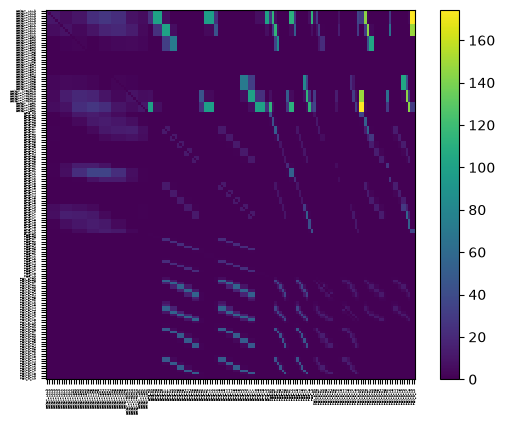

In [14]:
W_extrapolated_oos_mean_conn = extrapolator.extrapolate(parameters, set(COLUMNS) - set(EXTENDED_SAMPLE))
W_extrapolated_oos = np.zeros((len(ROIS), len(CELLS), len(CELLS)))

for ti, ii in enumerate(extrapolator.grouped["indices"]):
    for tj, jj in enumerate(extrapolator.grouped["indices"]):
        for r in range(len(ROIS)):
            W_extrapolated_oos[np.ix_([r], ii, jj)] = W_extrapolated_oos_mean_conn[r,ti,tj]

        if ti == tj:
            W_extrapolated_oos[:, ii, jj] = 0

plot_weights(W_extrapolated_oos.sum(0), cell_labels)

global std: 0.5001065679423371


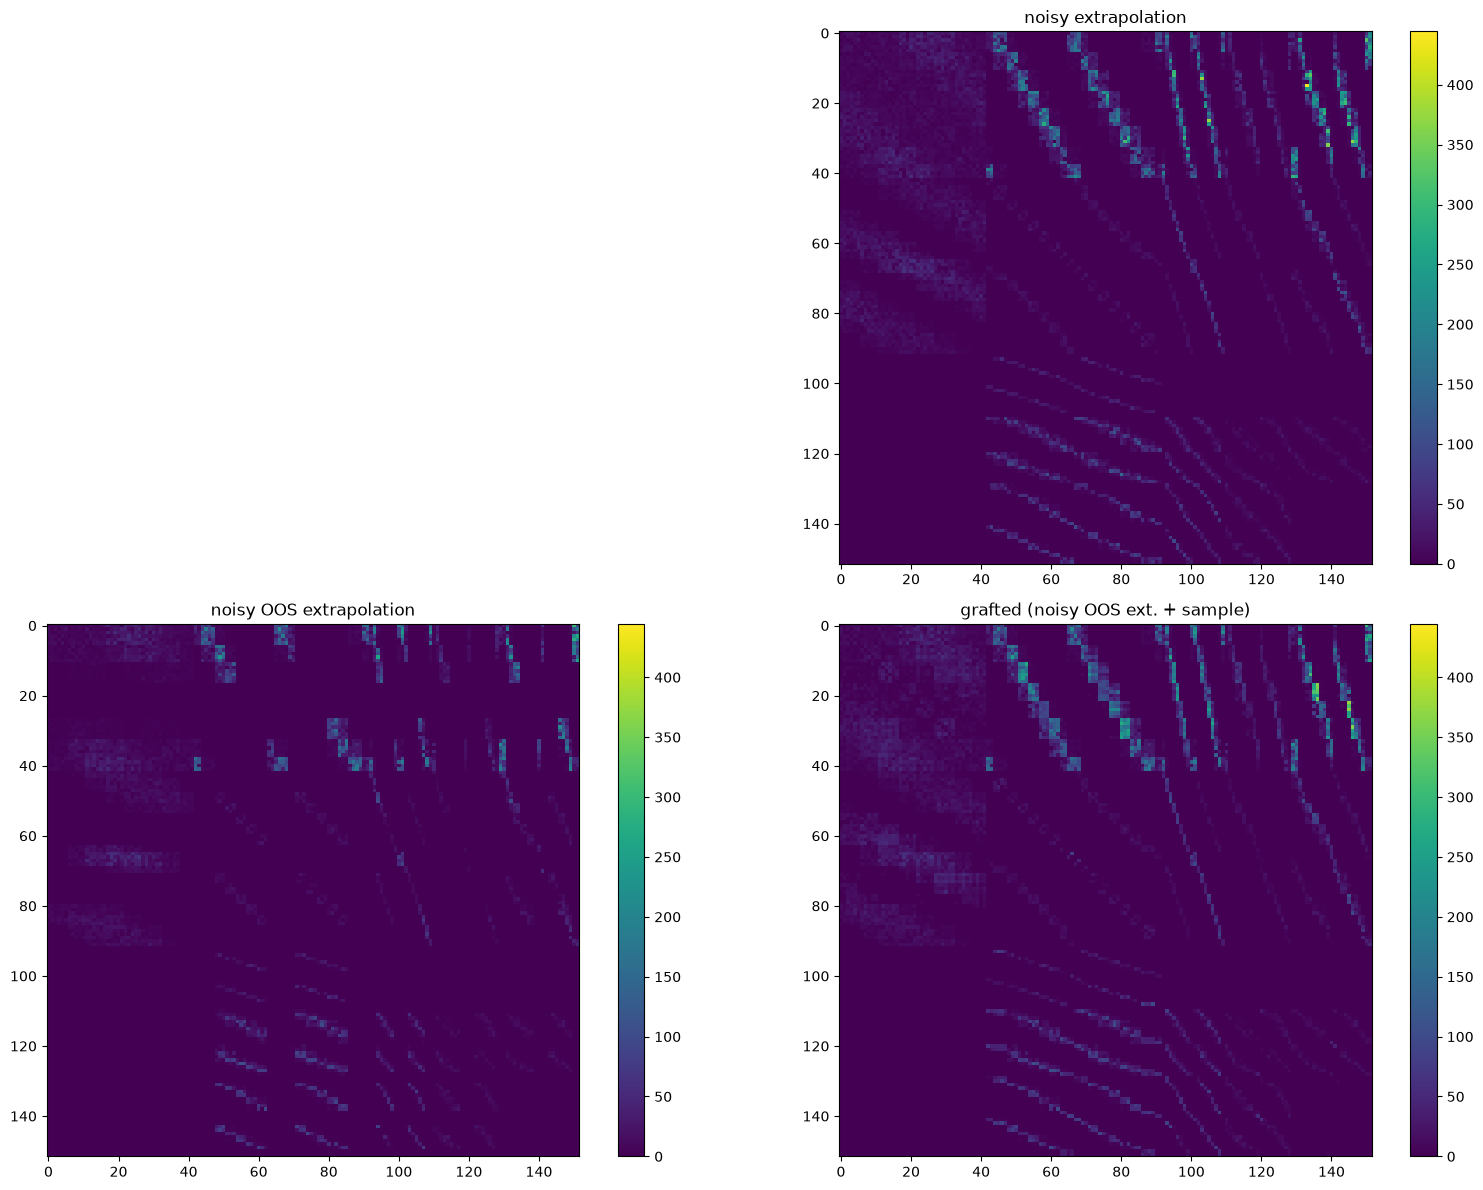

In [21]:
non_zero = (W_extrapolated > 10) #& (Ws > 10)
std = np.std(W_sample[non_zero] / W_extrapolated[non_zero])
print(f"global std: {std}")

W_extrapolated_noisy = np.maximum(0, W_extrapolated * np.random.normal(1, std, W_extrapolated.shape))
W_extrapolated_oos_noisy = np.maximum(0, W_extrapolated_oos * np.random.normal(1, std, W_extrapolated_oos.shape))
W_extrapolated_grafted = W_extrapolated_oos_noisy + W_sample_extended

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
norm = plt.Normalize(vmax=np.max([np.max(W_extrapolated_noisy), np.max(W_extrapolated_oos_noisy), np.max(W_extrapolated_grafted)]))
#ax1.set_title("ground truth")
#c = ax1.imshow(np.sum(W_ground, axis=0), interpolation="nearest", norm=norm)
#plt.colorbar(c)
ax1.remove()
ax2.set_title("noisy extrapolation")
c = ax2.imshow(np.sum(W_extrapolated_noisy, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
ax3.set_title("noisy OOS extrapolation")
c = ax3.imshow(np.sum(W_extrapolated_oos_noisy, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
ax4.set_title("grafted (noisy OOS ext. + sample)")
c = ax4.imshow(np.sum(W_extrapolated_grafted, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
plt.tight_layout()
plt.show()

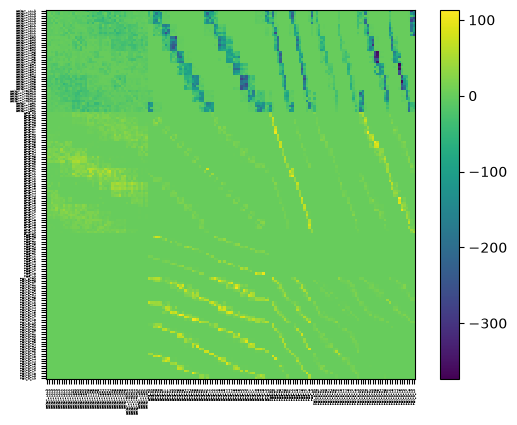

In [ ]:
W_extrapolated_grafted_signed = W_extrapolated_grafted.copy()
W_extrapolated_grafted_signed[:,CELLS["type"] == "Delta7",:] *= -1

np.save("../results/data/connectome/bee-grafted-full.npy", W_extrapolated_grafted_signed)
plot_weights(W_extrapolated_grafted_signed.sum(0), cell_labels)

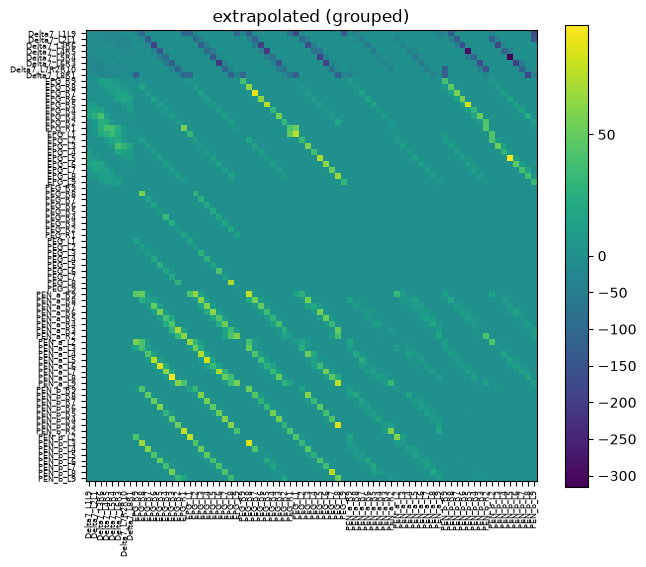

In [ ]:
from matplotlib.colors import TwoSlopeNorm

#W_ground_mean_input = extrapolator.mean_to_mean_input(extrapolator.group(W_ground))
W_extrapolated_mean_input = extrapolator.mean_to_mean_input(extrapolator.group(W_extrapolated_grafted))

#W_ground_mean_input_signed = W_ground_mean_input.copy()
#W_ground_mean_input_signed[:,:8,:] *= -1
W_extrapolated_mean_input_signed = W_extrapolated_mean_input.copy()
W_extrapolated_mean_input_signed[:,:8,:] *= -1
#print(np.max(W_ground_mean_input_signed))

np.save("../results/data/connectome/bee-grafted.npy", W_extrapolated_mean_input_signed)

norm = TwoSlopeNorm(
    vcenter = 0,
    vmin = np.min(W_extrapolated_mean_input_signed),
    vmax = np.max(W_extrapolated_mean_input_signed),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#ax1.set_title("ground truth (grouped)")
ax1.remove()
#plot_grouped_weights(W_ground_mean_input_signed.sum(0), grouped_labels, ax=ax1, norm=norm)
ax2.set_title("extrapolated (grouped)")
plot_grouped_weights(W_extrapolated_mean_input_signed.sum(0), grouped_labels, ax=ax2, norm=norm)
plt.show()